# Описание датасета 

В датасете представленны данные о пассажирах титаника:<br>
-PassengerId индетификатор пассажира <br>
-Survived выжил пассажир или нет, ключевая метрика вокруг которой буду проводить анализ и проверять гипотезы <br>
-Pclass	класс билета пассажира<br>
-Name имя пассажира<br>
-Sex гендер <br>
-Age возраст <br>
-SibSp колличество братьев и сестер на борту титаника <br>
-Parch колличество родителей и детей на борту титаника <br>
-Ticket номер билета <br>
-Fare стоимость проезда <br>
-Cabin каюта <br>
-Embarked порт посадки C = Шербур, Q = Квинстаун, S = Саутгемптон<br>

In [2]:
import kagglehub
import pandas as pd
import math 
import numpy as np
import seaborn as sns
from scipy import stats as st

In [3]:
# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\popka\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [4]:
try:
    df = pd.read_csv(path + '\\Titanic-Dataset.csv')
except:
    print('Ошибка открытия датасета')

# EDA

## Предобработка

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.shape

(891, 12)

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          714 non-null    float64
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  cabin        204 non-null    object 
 11  embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Пропуски в данных о возрасте и данных о каюте пассажира <br> С ними ничего делать не будем, просто для дальнейших исследований будем помнить об этом

In [10]:
df['age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [11]:
df[df['age'] == 0.67] 
#в интернете нашёл информацию о данном пассажире. 
#Ему действительно был 1 год в момент трагедии

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5,NaN,S


Округлю возраст пассажиров

In [12]:
df['age'] = df['age'].apply(np.ceil)

In [13]:
df['age'].unique()

array([22., 38., 26., 35., nan, 54.,  2., 27., 14.,  4., 58., 20., 39.,
       55., 31., 34., 15., 28.,  8., 19., 40., 66., 42., 21., 18.,  3.,
        7., 49., 29., 65.,  5., 11., 45., 17., 32., 16., 25.,  1., 30.,
       33., 23., 24., 46., 59., 71., 37., 47., 12.,  9., 51., 56., 41.,
       44., 61., 50., 36., 62., 52., 63., 43., 60., 10., 64., 13., 48.,
       53., 57., 80., 70.,  6., 74.])

In [14]:
#посмотрим количество полных дупликатов
df.duplicated().sum()

0

In [15]:
#посмотрим количество дупликатов по имени 
df.duplicated(subset = ['name']).sum()

0

## Анализ

In [16]:
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.714286,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526453,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.250000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Средний возраст пассажиров 30 лет, средний класс билета 2.3

In [17]:
round(df['survived'].mean(), 2)

0.38

Из представленных данных пассажиров титаника - доля выживших 38 %

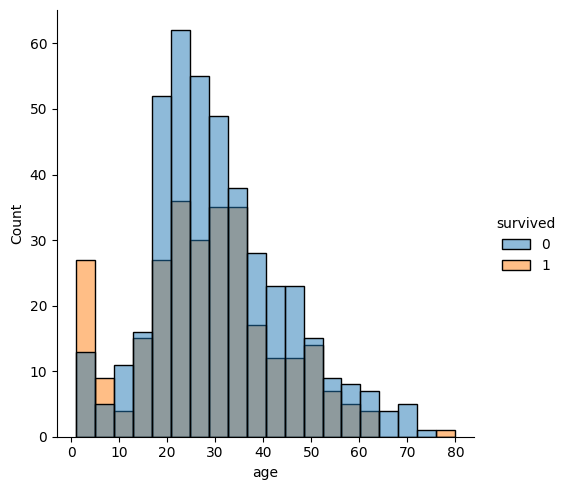

In [18]:
#посмотрим на график выживших/не выживших в зависимости от возраста
sns.displot(df, x = 'age', hue = 'survived');

По графику видно, что шанс выжить, а не погибнуть, был больше у детей до 10 лет. <br>
Думаю их спасали родители или старшие сестры/братья и в первую очередь их сажали в шлюпки,<br> ну и просто по моральным нормам спасать детей принято в первую очередь <br> <br> Так же близкий к 50/50 шанс на выживание имели люди в возрасте 35 и 50 лет. <br><br> самые плохие шансы выжить были у людей 65-75   

In [19]:
print(df['age'].max())
df[df['age'] == 80]['passengerid']

80.0


630    631
Name: passengerid, dtype: int64

In [20]:
df[df['passengerid'].isin([631])]

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,A23,S


В данных указан Mr. Algernon Henry Wilson и что ему 80 лет на момент крушения. Он выжил и он был пассажиром 1 класса.<br>
Но в интернете указано, что он умер в 80 лет в 1945 г., хотя Титаник затонул в 1912г.

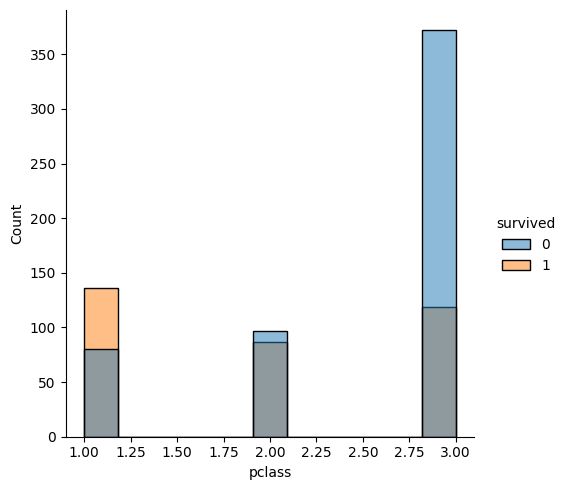

In [21]:
#посмотрим на график выживших/не выживших в зависимости от класса билета
sns.displot(df, x = 'pclass', hue = 'survived');

Пассажиры из первого класса больше выживали, из второго примерно 50/50, а люди из 3 класса имели наименьший шанс выжить.<br>
Видимо была привилегия в очереди на шлюпки или просто они находились ближе территориально к ним 

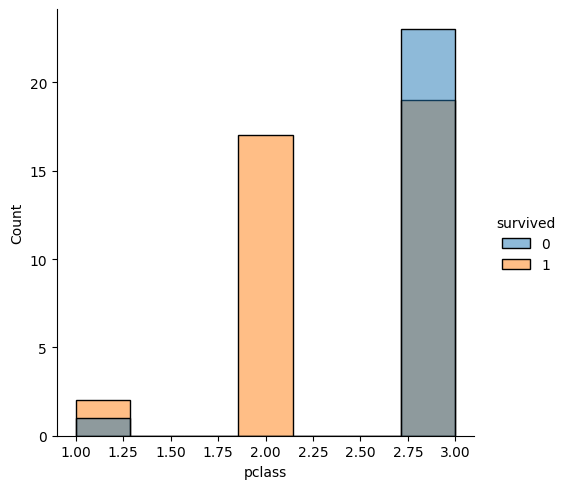

In [22]:
sns.displot(df[df['age'] < 10], x = 'pclass', hue = 'survived');

Дети до 10 лет из 2 класса выжили все в данном датасете, выживаемость детей в 3 классе выше чем у взрослых, но все равно больше смертей

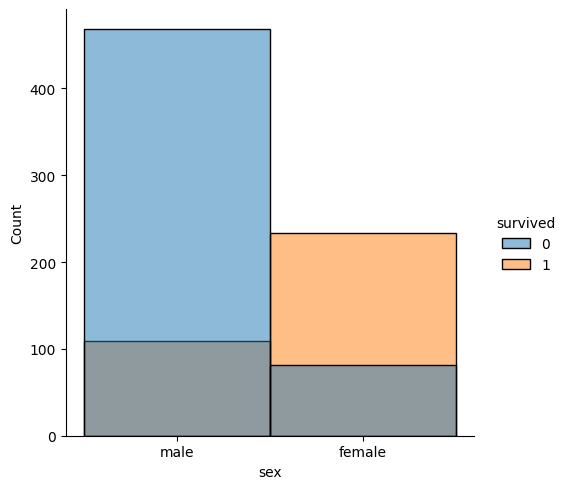

In [23]:
#посмотрим на график выживших/не выживших в зависимости от гендера
sns.displot(df, x = 'sex', hue = 'survived');

In [24]:
#Доля выживших мужчин
round(df[df['sex'] == 'male']['survived'].mean(),2)

0.19

In [25]:
#Доля выживших женщин
round(df[df['sex'] == 'female']['survived'].mean(),2)

0.74

Анализ показывает ситуацию похожую на фильм, где главный герой пожертвовал собой ради спасения любимой.<br> 
Процент выживших мужчин - 19, женщин - 74

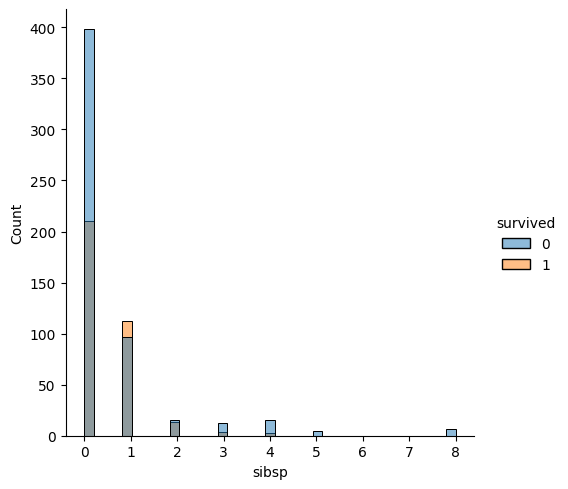

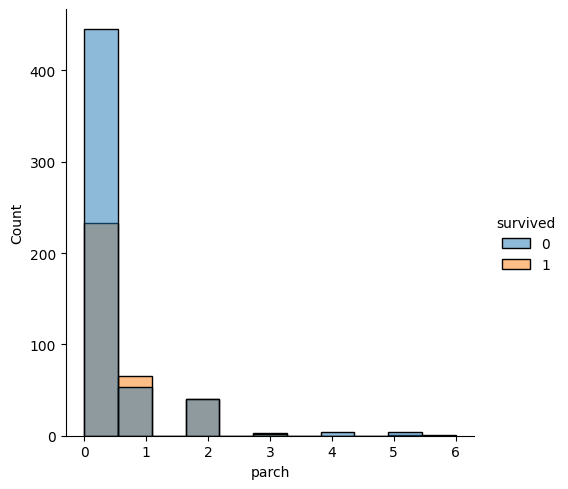

In [26]:
for i in ['sibsp', 'parch']:
    sns.displot(df, x = i, hue = 'survived');    

Пассажиры не имевшие никого из родни на борту погибали значительно чаще, чем пассажиры у которых кто-то был

In [27]:
#сделаю датафрейм с количеством братьев и сестер 1 или 2
df_parch = df[(df['sibsp'].isin([1, 2])) | (df['parch'].isin([1, 2]))]

In [28]:
# Выживаемость мужчин, имеющих родных на борту и возрастом более 10 лет
df_parch[(df_parch['sex'] == 'male') & (df_parch['age'] > 10)]['survived'].mean() 

0.19827586206896552

Взрослым мужчинам выживать родственники на борту не помогали, у них шанс выживаемости такой же как и у генеральной совокупности<br> 
Думаю потому что они спасали детей и жён.

In [29]:
df_parch[(df_parch['sex'] == 'female') & (df_parch['age'] > 10)]['survived'].mean() 

0.776

А вот у женщин выживаемость на 3 процента выше

In [30]:
#сводная таблица для классов билетов и их средней цены, максимальной, минимальной
df.groupby('pclass')['fare'].agg(['mean', 'max', 'min', 'count'])

,mean,max,min,count
pclass,,,,
1,84.154687,512.3292,0.0,216
2,20.662183,73.5000,0.0,184
3,13.675550,69.5500,0.0,491


Очень логично что чем выше класс билета, тем он дороже, но стоило проверить

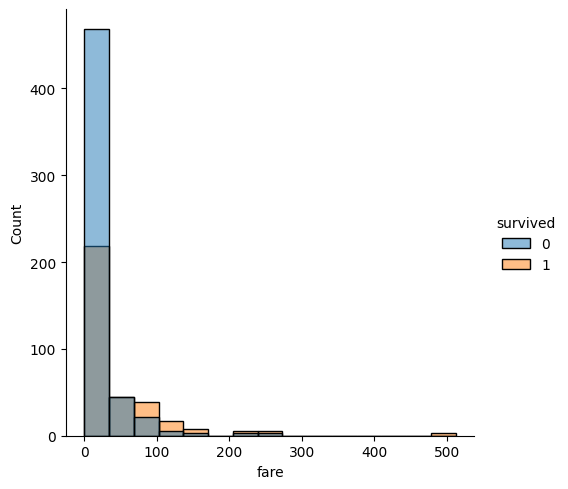

In [31]:
#посмотрим на график выживших/не выживших в зависимости от города посадки
sns.displot(df, x = 'fare', hue = 'survived',bins = 15,);

Видно по графику, что пассажиры с дорогими билетами выживали больше

In [32]:
df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [33]:
df.groupby('embarked')[['pclass','survived']].agg(['mean','count'])

pclass        survived      
              mean count      mean count
embarked                                
C         1.886905   168  0.553571   168
Q         2.909091    77  0.389610    77
S         2.350932   644  0.336957   644

Пассажиры из Шербура больше всех выживали и имеют в среднем лучшие классы билетов.<br>
Хотя пассажиры из Квинстаун имеют в среднем билеты хуже, чем у Саутгемптона, но выживаемость составила у них большую долю.<BR> Но оценивать это не целесообразно так как велечина выборки пассажиров из Саутгемптона гораздо выше

## Проверка гипотез

Нулевая и альтернативная гипотезы:<br>
Гипотеза Н0: Средний возраст выживших равен среднему возрасту пассажиров, которым не удалось выжить<br>
Гипотеза Н1: Средний возраст выживших пассажиров меньше, чем средний возраст пассажиров, которым не удалось выжить

In [34]:
df_surv = df[df['survived'] == 1]
df_no_surv = df[df['survived'] == 0]

In [35]:
#проверим наше количество выборки, чтобы понять добавлять equal_var=False или нет
print(df_surv['passengerid'].count())
df_no_surv['passengerid'].count()

342


549

In [36]:
df_surv['age'].mean()

28.351724137931033

In [37]:
df_no_surv['age'].mean()

30.64622641509434

In [38]:
alpha = 0.05 # уровень статистической значимости
# если p-value окажется меньше него, отвергнем гипотезу

results = st.ttest_ind(df_surv['age'].dropna(), df_no_surv['age'].dropna(), alternative='less')
print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.019050363407048906
Отвергаем нулевую гипотезу


Отвергаем нулевую гипотезу.<br> Значит можно сделать выводы, что средний возраст выживших пассажиров все таки ниже умерших

In [39]:
round(df['parch'].mean(),1)

0.4

Гипотеза Н0: Среднее количество детей и родителей на борту у выживших пассажиров равно 0,4<br>
Гипотеза Н1: Среднее количество детей и родителей на борту у выживших пассажиров менее 0,4

In [40]:
results = st.ttest_1samp(df_surv['parch'].dropna(), 0.4, alternative='less')
print(results.pvalue)
if results.pvalue < 0.05:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

0.939628933195352
Не получилось отвергнуть нулевую гипотезу


Отвергнуть нулевую гипотезу не удалось. Значит количество родителей и детей у выживших примерно такое же как и у генеральной выборки

Выводы по анализу: Шансы выжить больше у молодых людей, у людей из первого класса и у женщин